## **SETUP**

In [ ]:
# Imports
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn import datasets
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.cluster import DBSCAN

plt.rcParams['axes.facecolor'] = '#595959'
plt.rcParams['text.color'] = 'black'
plt.rcParams['axes.labelcolor'] = 'black'
plt.rcParams['xtick.color'] = 'black'
plt.rcParams['ytick.color'] = 'black'
titlefont = {'fontname':'Lexend'}
bodyfont = {'fontname':'Avenir'}

# Loading CSVs
dfSales = pd.read_csv('SalesData.csv')
dfLoyalty = pd.read_csv('LoyaltyData.csv')
dfLocation = pd.read_csv('LocationData.csv')
dfFeedback = pd.read_csv('FeedbackData.csv')
# print(dfSales)
# print(dfLoyalty)
# print(dfLocation)
# print(dfFeedback)


Note: Every time you run one of these code cells, must run setup code cell first

# **DF Construction: Revenue, Profit Margin, & Quantity Sold by Location**

In [ ]:
# drop irrelevant columns
dfSales = dfSales.drop(columns = ['TransactionID', 'Date', 'ProductType', 'PurchaseMethod'])
dfLocation = dfLocation.drop(columns = ['LocationType', 'FootTraffic', 'AvgMonthlySales', 'DemographicAge', 'MedianIncome', 'CoffeeConsumptionIndex'])

# new df incorporates average revenue, mean and standard deviation
df_stats = dfSales.groupby('LocationID')['Revenue'].agg(['sum','mean', 'std']).reset_index()
df_stats = df_stats.rename(columns={'sum': 'TotalRevenue', 'mean': 'AverageRevenue', 'std': 'RevenueStDev'})

# merge w/ location df
merged_df = pd.merge(dfLocation, df_stats, on = 'LocationID', how = 'inner')

# Repeat process for Profit Margin
df_stats = dfSales.groupby('LocationID')['ProfitMargin'].agg(['sum','mean', 'std']).reset_index()
df_stats = df_stats.rename(columns={'sum': 'TotalProfitMargin', 'mean': 'AverageProfitMargin', 'std': 'ProfitMarginStDev'})
merged_df = pd.merge(merged_df, df_stats, on = 'LocationID', how = 'inner')

# Repeat process for Quantity Sold
df_stats = dfSales.groupby('LocationID')['QuantitySold'].agg(['sum','mean', 'std']).reset_index()
df_stats = df_stats.rename(columns={'sum': 'TotalSold', 'mean': 'AverageQuantitySold', 'std': 'QuantitySoldStDev'})
merged_df = pd.merge(merged_df, df_stats, on = 'LocationID', how = 'inner')
print(merged_df)

# Save the dataframe as a csv
merged_df.to_csv('Location_vs_Revenue_ProfitMargin.csv')


    LocationID            City  TotalRevenue  AverageRevenue  RevenueStDev  \
0            1         Seattle       1668.41        7.448259      2.580622   
1            2        Portland       1662.50        7.661290      2.680474   
2            3          Eugene       1932.23        7.403180      2.575236   
3            4         Spokane       1904.54        7.439609      2.552418   
4            5          Tacoma       2120.09        7.438912      2.599510   
5            6  Vancouver (WA)       1664.89        7.270262      2.573399   
6            7        Bellevue       1598.33        7.298311      2.685271   
7            8         Olympia       1590.78        7.364722      2.566616   
8            9           Salem       2049.81        7.320750      2.517536   
9           10            Bend       1753.24        7.274855      2.578715   
10          11           Boise       1773.75        7.484177      2.629323   
11          12          Yakima       1849.59        7.196848    

# **DF Construction: Revenue, Profit Margin, & Quantity Sold by Product Type**

In [ ]:
# drop irrelevant cols
dfSales = dfSales.drop(columns = ['TransactionID', 'Date', 'LocationID', 'PurchaseMethod'])
dfSales = dfSales.dropna()

# making new df and adding total, mean, and standard deviation
df_stats = dfSales.groupby('ProductType')['Revenue'].agg(['sum','mean', 'std']).reset_index()
df_stats = df_stats.rename(columns={'sum': 'TotalRevenue','mean': 'AverageRevenue', 'std': 'RevenueStDev'})


df_stats2 = dfSales.groupby('ProductType')['ProfitMargin'].agg(['sum', 'mean', 'std']).reset_index()
df_stats2 = df_stats2.rename(columns={'sum': 'TotalProfitMargin','mean': 'AverageProfitMargin', 'std': 'ProfitMarginStDev'})
merged_df = pd.merge(df_stats, df_stats2, on = 'ProductType', how = 'inner')


df_stats = dfSales.groupby('ProductType')['QuantitySold'].agg(['sum', 'mean', 'std']).reset_index()
df_stats = df_stats.rename(columns={'sum' : 'TotalSold', 'mean': 'AverageQuantity', 'std': 'QuantityStDev'})
merged_df = pd.merge(merged_df, df_stats, on = 'ProductType', how = 'inner')

print(merged_df)

      ProductType  TotalRevenue  AverageRevenue  RevenueStDev  \
0          Coffee       7483.20        7.490691      2.613891   
1          Pastry       7229.43        7.507196      2.627908   
2        Sandwich       7334.04        7.408121      2.525611   
3  Seasonal Drink       7300.01        7.292717      2.532342   
4             Tea       7009.27        7.401552      2.586338   

   TotalProfitMargin  AverageProfitMargin  ProfitMarginStDev  TotalSold  \
0             249.97             0.250220           0.087040       2547   
1             243.15             0.252492           0.088028       2439   
2             247.01             0.249505           0.088315       2453   
3             247.15             0.246903           0.086601       2452   
4             237.35             0.250634           0.084379       2358   

   AverageQuantity  QuantityStDev  
0         2.549550       1.119734  
1         2.532710       1.113945  
2         2.477778       1.127383  
3         2.44

In [ ]:
merged_df.to_csv('ProductType_vs_RevPMQS.csv')

# **DF Construction: Purchase Method & Product Type by Location**

In [ ]:
# drop irrelevant columns
dfSales = dfSales.drop(columns = ['TransactionID', 'Date', 'Revenue', 'ProfitMargin'])
dfLocation = dfLocation.drop(columns = ['LocationType', 'FootTraffic', 'AvgMonthlySales', 'DemographicAge', 'MedianIncome', 'CoffeeConsumptionIndex'])

# count occurrences of each combination of location/product type, repeat for purchase method
count_product_type = dfSales.groupby(['LocationID', 'ProductType'])['QuantitySold'].sum().reset_index(name='TotalQuantitySold')
count_purchase_method = dfSales.groupby(['LocationID', 'PurchaseMethod']).size().reset_index(name='Count')

# merge on location ID
product_type = pd.merge(dfLocation, count_product_type, on = 'LocationID', how = 'inner')
purchase_method = pd.merge(dfLocation, count_purchase_method, on = 'LocationID', how = 'inner')

print(product_type)




In [ ]:
product_type.to_csv('Location_vs_ProductType.csv')
#purchase_method.to_csv('Location_vs_PurchaseMethod.csv')

# **DF Construction: Average Monthly Sales by Customer Age, Median Income, & Coffee Consumption**

In [ ]:
#dfLocation = dfLocation.drop(columns = ['FootTraffic', 'LocationID', 'City', 'LocationType'])

# AMR vs Age
df_stats = dfLocation.groupby('DemographicAge')['AvgMonthlySales'].agg(['sum','mean', 'std']).reset_index()
df_age = df_stats.rename(columns={'sum': 'TotalAverage', 'mean': 'MeanAverage', 'std': 'AverageStDev'})

print(df_age)

# AMR vs Income
df_income = dfLocation.drop(columns = ['CoffeeConsumptionIndex', 'DemographicAge'])
print(df_income)

# AMR vs Coffee Consumption Index
df_consumption = dfLocation.drop(columns = ['MedianIncome', 'DemographicAge'])
print(df_consumption)





In [ ]:
df_age.to_csv('Age_vs_AMR.csv')
df_income.to_csv('Income_vs_AMR.csv')
df_consumption.to_csv('CoffeeConsumptionIndex_vs_AMR.csv')

# **DF Construction: Location vs. Average Sentiment Score**

In [ ]:
# Remove irrelevant columns
#dfLoyalty = dfFeedback.drop(columns = ['ReviewID', 'ReviewKeywords'])
#dfLocation = dfLocation.drop(columns = ['LocationType', 'FootTraffic', 'AvgMonthlySales', 'DemographicAge', 'MedianIncome', 'CoffeeConsumptionIndex'])

# Make new DF (df_stats)
df_stats = dfFeedback.groupby('LocationID')['SentimentScore'].agg(['sum','mean', 'std']).reset_index()
df_stats = df_stats.rename(columns={'sum': 'TotalSentiment', 'mean': 'AverageSentiment', 'std': 'SentimentStDev'})

merged_df = pd.merge(dfLocation, df_stats, on = 'LocationID', how = 'inner')

print(merged_df)

In [ ]:
# Save the dataframes as csvs
merged_df.to_csv('Location_vs_Sentiment.csv')

# **DF Construction: Locations vs. Review Type**

In [ ]:
#dfLocation = dfLocation.drop(columns = ['LocationType', 'FootTraffic', 'AvgMonthlySales', 'DemographicAge', 'MedianIncome', 'CoffeeConsumptionIndex'])

# Count/group similar reviews
count_keyword = dfFeedback.groupby(['LocationID', 'ReviewKeywords']).size().reset_index(name='Count')

# merge on location ID
keyword = pd.merge(dfLocation, count_keyword, on = 'LocationID', how = 'inner')

print(keyword)

In [ ]:
keyword.to_csv('Location vs Reviews.csv')

# **ML Model**

Noise CoffeeConsumptionIndex:
6     3.00
8     1.21
17    1.93
19    2.52
Name: CoffeeConsumptionIndex, dtype: float64
Cluster 1 CoffeeConsumptionIndex:
0     4.86
2     1.77
3     1.13
13    3.80
15    4.05
16    4.32
Name: CoffeeConsumptionIndex, dtype: float64
Cluster 2 CoffeeConsumptionIndex:
1     1.81
4     2.32
11    2.85
Name: CoffeeConsumptionIndex, dtype: float64
Cluster 3 CoffeeConsumptionIndex:
5     1.10
7     3.02
9     1.96
10    4.33
12    2.74
14    3.86
18    1.27
Name: CoffeeConsumptionIndex, dtype: float64


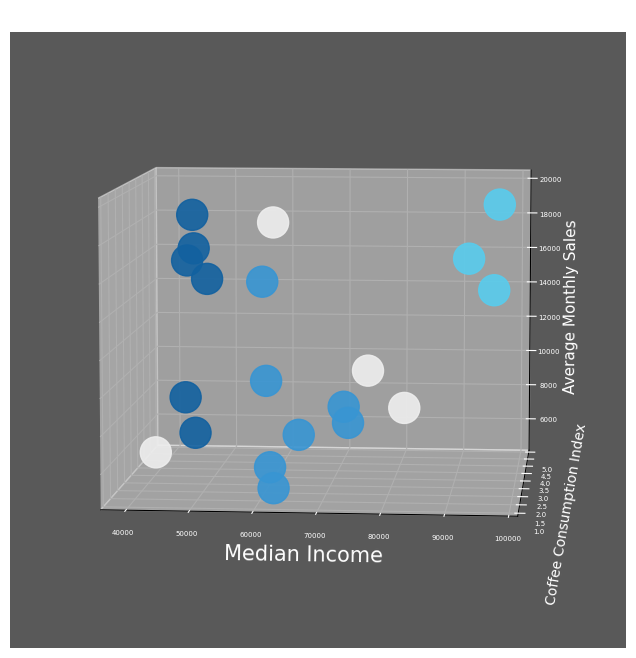

In [ ]:
# turn relevant columns into readable numpy array
X = dfLocation[['MedianIncome', 'CoffeeConsumptionIndex', 'AvgMonthlySales']].to_numpy()
# CCI and Median Income - strong general positive correlations with sales

# fit DBSCAN model
dbscan = DBSCAN(eps=5500, min_samples=2)
label_arr = dbscan.fit_predict(X)

# unique cluster labels (noise is -1)
unique_labels = np.unique(label_arr)

# Hoyalytics colors
color_mapping = {
    -1: '#eeeeee',
    0: '#1261a0',
    1: '#58cced',
    2: '#3895d3',
}

# make plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# plotting
for label in unique_labels:
    if label == -1:
        cluster_name = 'Noise'
    else:
        cluster_name = f'Cluster {label + 1}'

    ax.scatter(
        X[label_arr == label, 0],
        X[label_arr == label, 1],
        X[label_arr == label, 2],
        c=[color_mapping[label]],
        label=cluster_name,
        alpha=0.9, # transparency
        s=500 # size
    )

# formatting
ax.set_xlabel('Median Income', fontsize=15)
ax.set_ylabel('Coffee Consumption Index', fontsize=10)
ax.set_zlabel('Average Monthly Sales', fontsize=11)
ax.set_title('DBSCAN Clustering')
ax.tick_params(axis='x', labelsize=5)
ax.tick_params(axis='y', labelsize=5)
ax.tick_params(axis='z', labelsize=5)

ax.view_init(elev=7, azim=275)
plt.show()